Mounted at /content/drive
✅ Libraries loaded
✅ Config loaded
   Datasets         : 11
   Train/Test       : 70% / 30%
   n_estimators     : 100
   max_depth        : 4
   learning_rate    : 0.1
   scale_pos_weight : 1.5
  XGBoost — Training & Evaluation on 11 Datasets

────────────────────────────────────────────────────────────
  Dataset : AAC  (AAC_features.csv)
  Shape   : (2190, 21)  |  Features: 20  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples

  ── Results ──────────────────────────────────────
  Accuracy    : 0.7930
  Sensitivity : 0.7376
  Specificity : 0.8299
  F1 Score    : 0.7405
  MCC         : 0.5683
  AUC         : 0.8265
  TP=194  TN=327  FP=67  FN=69
  Probabilities saved → /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/xgboost/AAC_XGB_probabilities.csv

────────────────────────────────────────────────────────────
  Dataset : DPC  (DPC_features.csv)
  Shape   : (2190, 401)  |  Features: 400  |  Pos: 876  Neg: 1314
  Train   : 1533

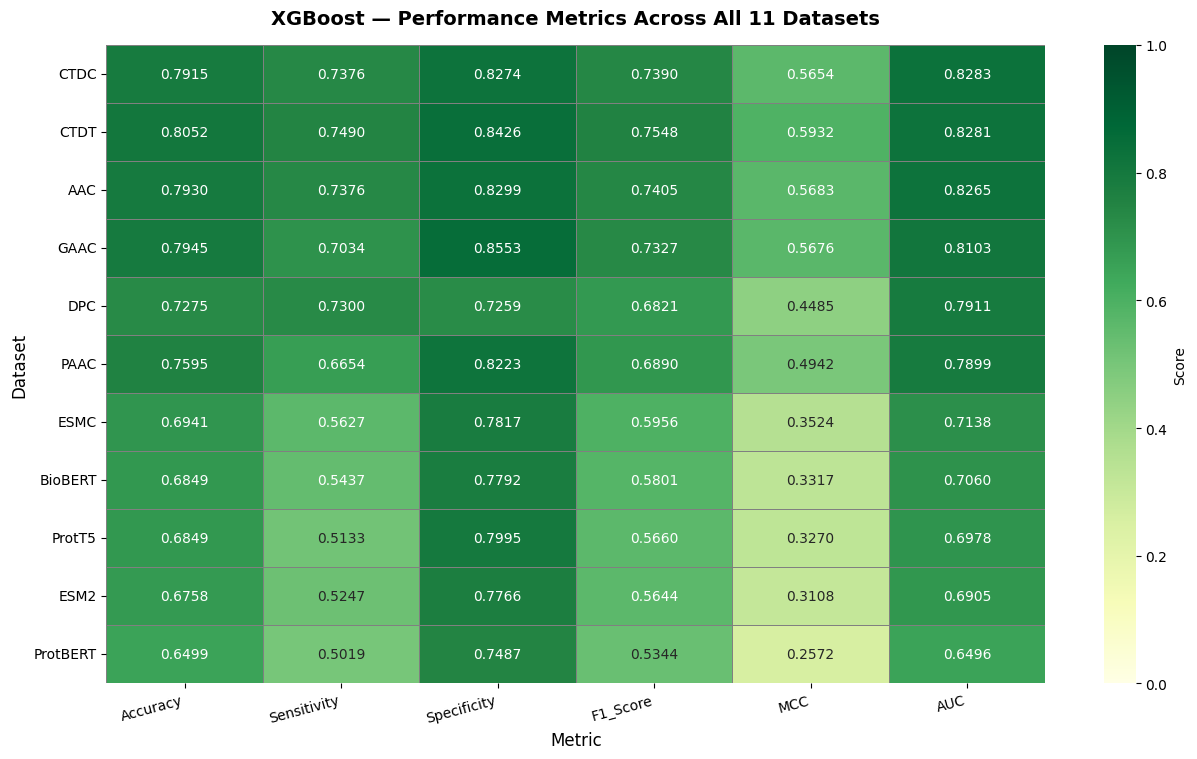

✅ Metrics heatmap saved


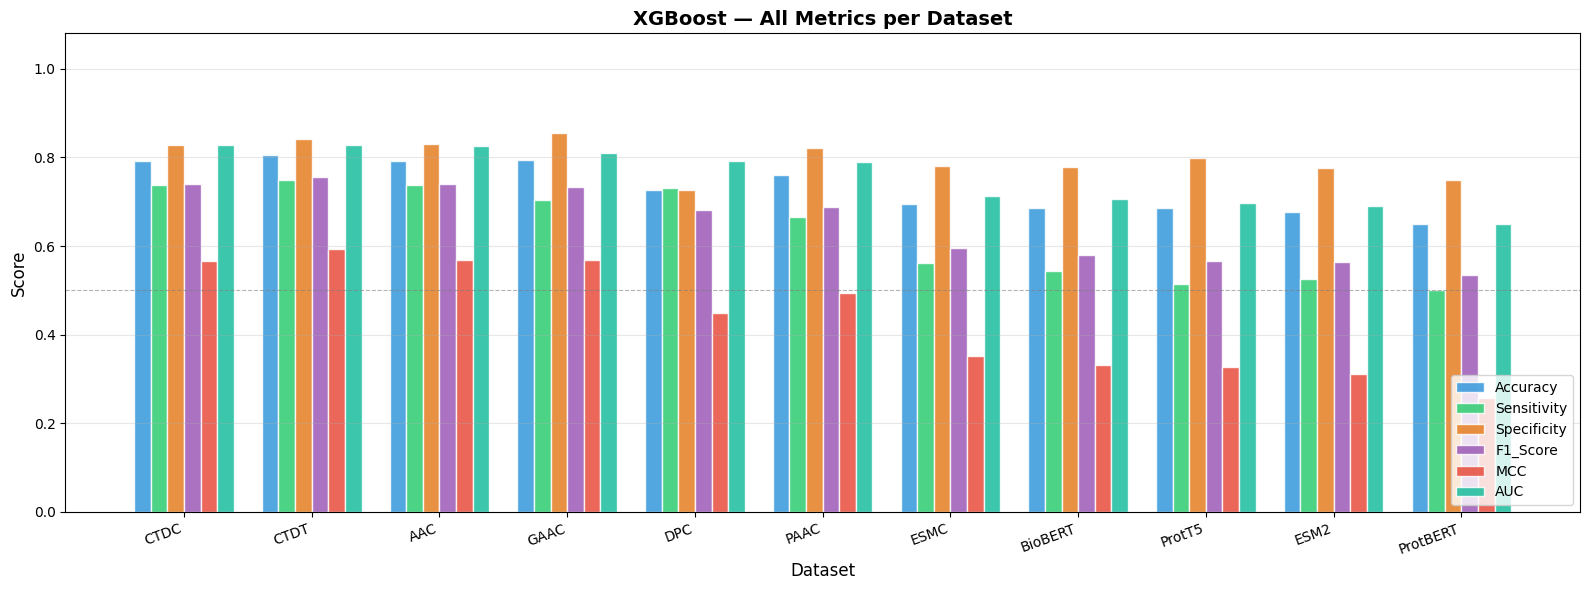

✅ Grouped bar chart saved


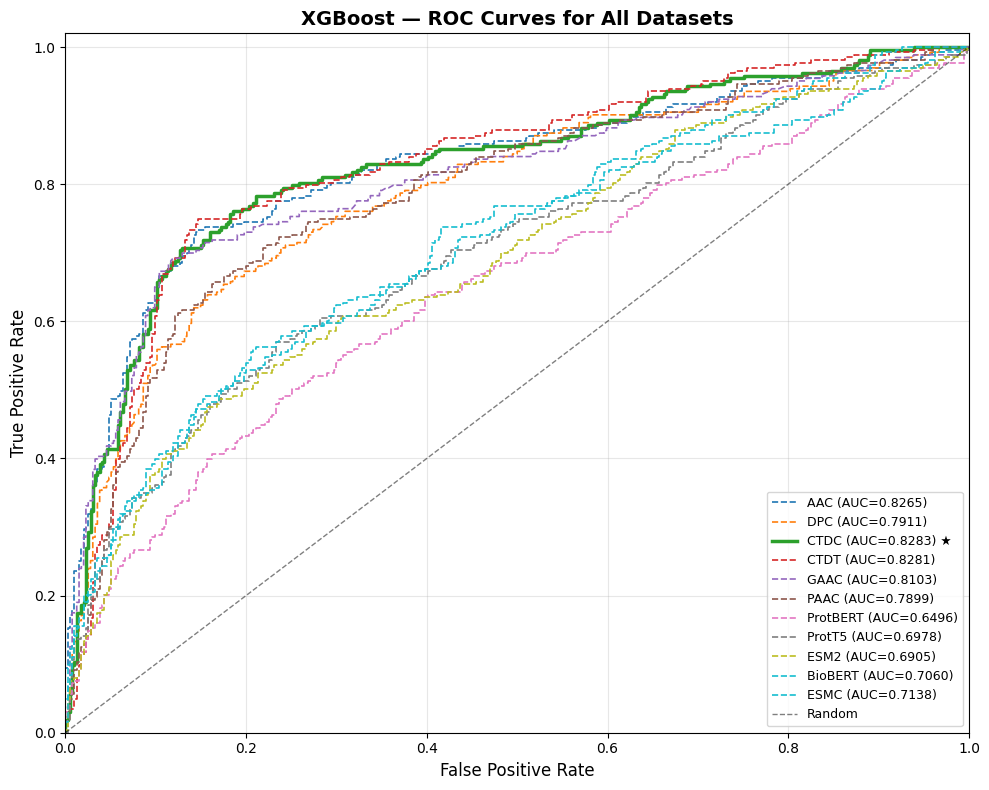

✅ ROC curves saved


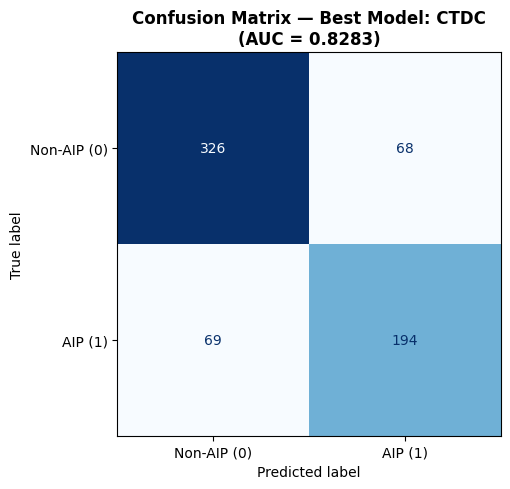

✅ Confusion matrix saved (CTDC)


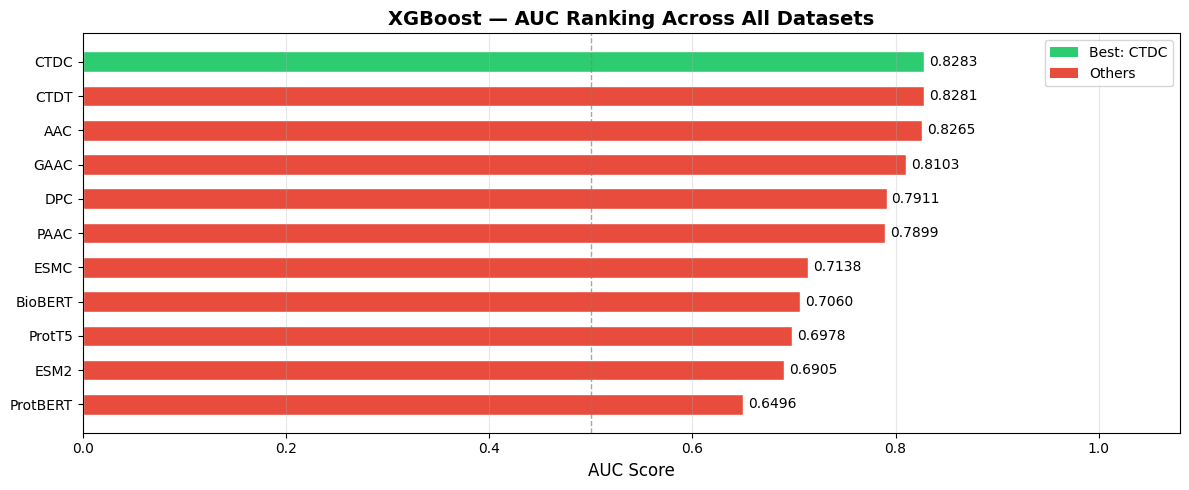

✅ AUC ranking chart saved


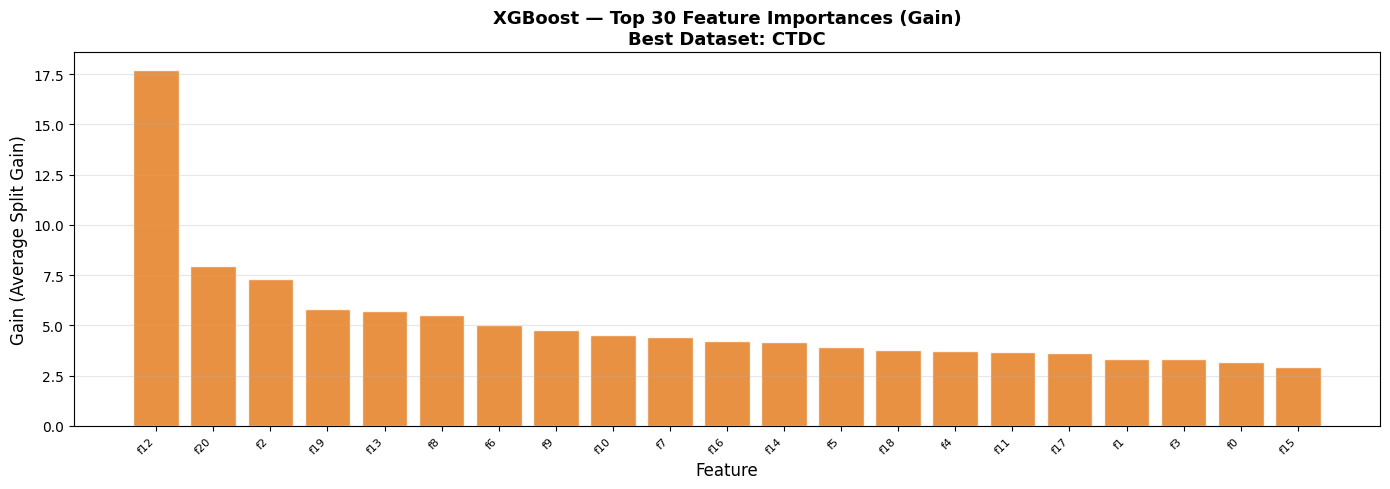

✅ Feature importance plot saved (CTDC)
  XGBOOST — FINAL SUMMARY

  Results saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/xgboost
  Figures saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/xgboost
  Model saved to    : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/xgboost

─────────────────────────────────────────────────────────────────
  Dataset           Acc       Sn       Sp       F1      MCC      AUC
─────────────────────────────────────────────────────────────────
  CTDC           0.7915   0.7376   0.8274   0.7390   0.5654   0.8283 ★
  CTDT           0.8052   0.7490   0.8426   0.7548   0.5932   0.8281
  AAC            0.7930   0.7376   0.8299   0.7405   0.5683   0.8265
  GAAC           0.7945   0.7034   0.8553   0.7327   0.5676   0.8103
  DPC            0.7275   0.7300   0.7259   0.6821   0.4485   0.7911
  PAAC           0.7595   0.6654   0.8223   0.6890   0.4942   0.7899
  ESMC           0.6941   0.5627 

In [1]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install & Import Libraries
# ============================================================
!pip install xgboost -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

print("✅ Libraries loaded")


# ============================================================
#   CELL 3 — Configuration
# ============================================================

FEATURE_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/data/features"
RESULTS_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/xgboost"
FIGURES_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/xgboost"
MODELS_DIR   = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/xgboost"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── All 11 feature datasets ──────────────────────────────────
DATASETS = {
    "AAC"     : "AAC_features.csv",
    "DPC"     : "DPC_features.csv",
    "CTDC"    : "CTDC_features.csv",
    "CTDT"    : "CTDT_features.csv",
    "GAAC"    : "GAAC_features.csv",
    "PAAC"    : "PAAC_features.csv",
    "ProtBERT": "ProtBERT_features.csv",
    "ProtT5"  : "ProtT5_features.csv",
    "ESM2"    : "ESM2_features.csv",
    "BioBERT" : "BioBERT_features.csv",
    "ESMC"    : "ESMC_features.csv",
}

# ── XGBoost hyperparameters ──────────────────────────────────
#
#  Key XGBoost parameters:
#    n_estimators    : number of boosting rounds (trees)
#                      100 is safe default; 200–500 for better accuracy
#    max_depth       : max tree depth — deeper = more complex, more overfit risk
#                      3–6 is typical; use 4 as balanced default
#    learning_rate   : step size shrinkage — lower = more robust, slower
#                      0.1 is standard; try 0.05 with more estimators
#    subsample       : fraction of samples per tree — reduces overfitting
#    colsample_bytree: fraction of features per tree — like max_features in RF
#    scale_pos_weight: handles class imbalance
#                      set to neg_count / pos_count  (≈ 1314/876 ≈ 1.5 here)
#    eval_metric     : "logloss" for binary classification
#    use_label_encoder: False — avoids deprecation warning
#    tree_method     : "hist" is fast; "gpu_hist" if GPU available
#
XGB_PARAMS = {
    "n_estimators"      : 100,
    "max_depth"         : 4,
    "learning_rate"     : 0.1,
    "subsample"         : 0.8,
    "colsample_bytree"  : 0.8,
    "scale_pos_weight"  : 1.5,       # neg / pos ratio ≈ 1314/876
    "eval_metric"       : "logloss",
    "use_label_encoder" : False,
    "tree_method"       : "hist",    # use "gpu_hist" if GPU available
    "random_state"      : 42,
    "n_jobs"            : -1,
}

TEST_SIZE    = 0.30
RANDOM_STATE = 42

print(f"✅ Config loaded")
print(f"   Datasets         : {len(DATASETS)}")
print(f"   Train/Test       : {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%")
print(f"   n_estimators     : {XGB_PARAMS['n_estimators']}")
print(f"   max_depth        : {XGB_PARAMS['max_depth']}")
print(f"   learning_rate    : {XGB_PARAMS['learning_rate']}")
print(f"   scale_pos_weight : {XGB_PARAMS['scale_pos_weight']}")


# ============================================================
#   CELL 4 — Metric Helper Functions
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    """
    Compute all 6 performance metrics.

    Metrics:
      Accuracy    = (TP + TN) / (TP + TN + FP + FN)
      Sensitivity = TP / (TP + FN)   [Recall for positive class]
      Specificity = TN / (TN + FP)   [Recall for negative class]
      F1 Score    = 2 × (Precision × Recall) / (Precision + Recall)
      MCC         = Matthews Correlation Coefficient
      AUC         = Area Under ROC Curve
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy    = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, y_pred, zero_division=0)
    mcc         = matthews_corrcoef(y_true, y_pred)
    auc         = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy"   : round(accuracy,    4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "F1_Score"   : round(f1,          4),
        "MCC"        : round(mcc,         4),
        "AUC"        : round(auc,         4),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
    }


def load_dataset(csv_path):
    """
    Load a feature CSV, auto-detect feature columns and label.
    Expects: seq_id column, feature columns, label column (last).
    """
    df = pd.read_csv(csv_path)

    drop_cols = [c for c in ["seq_id", "sequence", "length"]
                 if c in df.columns]
    df = df.drop(columns=drop_cols)

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)   # XGBoost requires int labels

    return X, y, df.columns[-1], df.shape


# ============================================================
#   CELL 5 — Main Training Loop
# ============================================================

all_results  = []
best_model   = None
best_scaler  = None
best_name    = ""
best_auc     = -1.0
all_probs    = {}

print("=" * 65)
print("  XGBoost — Training & Evaluation on 11 Datasets")
print("=" * 65)

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)

    if not os.path.exists(csv_path):
        print(f"\n⏭  [{ds_name}] File not found — skipping: {csv_file}")
        continue

    print(f"\n{'─'*60}")
    print(f"  Dataset : {ds_name}  ({csv_file})")

    # ── Load & split ─────────────────────────────────────────
    X, y, label_col, shape = load_dataset(csv_path)
    print(f"  Shape   : {shape}  |  Features: {X.shape[1]}  |  "
          f"Pos: {y.sum()}  Neg: {(y==0).sum()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y
    )

    print(f"  Train   : {len(X_train)} samples  |  "
          f"Test: {len(X_test)} samples")

    # ── Scale features ───────────────────────────────────────
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── Train XGBoost ────────────────────────────────────────
    clf = XGBClassifier(**XGB_PARAMS)
    clf.fit(
        X_train, y_train,
        eval_set         = [(X_test, y_test)],
        verbose          = False
    )

    # ── Predict ──────────────────────────────────────────────
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # ── Metrics ──────────────────────────────────────────────
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["Dataset"]  = ds_name
    metrics["Features"] = X.shape[1]
    metrics["Train_N"]  = len(X_train)
    metrics["Test_N"]   = len(X_test)
    all_results.append(metrics)

    print(f"\n  ── Results ──────────────────────────────────────")
    print(f"  Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"  Specificity : {metrics['Specificity']:.4f}")
    print(f"  F1 Score    : {metrics['F1_Score']:.4f}")
    print(f"  MCC         : {metrics['MCC']:.4f}")
    print(f"  AUC         : {metrics['AUC']:.4f}")
    print(f"  TP={metrics['TP']}  TN={metrics['TN']}  "
          f"FP={metrics['FP']}  FN={metrics['FN']}")

    # ── Save probabilities ───────────────────────────────────
    df_probs = pd.DataFrame({
        "y_true"       : y_test,
        "y_pred"       : y_pred,
        "prob_positive": y_prob,
        "prob_negative": 1 - y_prob,
    })
    prob_path = os.path.join(RESULTS_DIR, f"{ds_name}_XGB_probabilities.csv")
    df_probs.to_csv(prob_path, index=False)

    all_probs[ds_name] = {
        "y_test": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "clf"   : clf,
        "scaler": scaler,
    }

    # ── Track best model ─────────────────────────────────────
    if metrics["AUC"] > best_auc:
        best_auc    = metrics["AUC"]
        best_name   = ds_name
        best_model  = clf
        best_scaler = scaler

    print(f"  Probabilities saved → {prob_path}")

print(f"\n{'='*65}")
print(f"  ✅ Training complete for {len(all_results)} datasets")
print(f"  🏆 Best model: {best_name}  (AUC = {best_auc:.4f})")
print(f"{'='*65}")


# ============================================================
#   CELL 6 — Results Summary Table
# ============================================================

metric_cols = ["Dataset", "Accuracy", "Sensitivity", "Specificity",
               "F1_Score", "MCC", "AUC", "Features"]

df_results = pd.DataFrame(all_results)[metric_cols].sort_values(
    "AUC", ascending=False
).reset_index(drop=True)

df_results.index += 1

print("\n── XGBoost Performance Summary (sorted by AUC) ──")
print(df_results.to_string())

summary_path = os.path.join(RESULTS_DIR, "XGB_all_results_summary.csv")
df_results.to_csv(summary_path, index=True, index_label="Rank")
print(f"\n✅ Summary saved → {summary_path}")


# ============================================================
#   CELL 7 — Save Best Model
# ============================================================

best_model_path  = os.path.join(MODELS_DIR, f"XGB_best_model_{best_name}.joblib")
best_scaler_path = os.path.join(MODELS_DIR, f"XGB_best_scaler_{best_name}.joblib")

joblib.dump(best_model,  best_model_path)
joblib.dump(best_scaler, best_scaler_path)

# Also save in native XGBoost format (.json) for portability
xgb_json_path = os.path.join(MODELS_DIR, f"XGB_best_model_{best_name}.json")
best_model.save_model(xgb_json_path)

print(f"✅ Best model saved")
print(f"   Dataset    : {best_name}")
print(f"   AUC        : {best_auc:.4f}")
print(f"   Model      : {best_model_path}")
print(f"   Model JSON : {xgb_json_path}")
print(f"   Scaler     : {best_scaler_path}")


# ============================================================
#   CELL 8 — Visualization 1: Metrics Heatmap (All Datasets)
# ============================================================

heat_cols = ["Accuracy", "Sensitivity", "Specificity", "F1_Score", "MCC", "AUC"]
heat_data = df_results.set_index("Dataset")[heat_cols]

fig, ax = plt.subplots(figsize=(13, max(5, len(heat_data) * 0.7)))

sns.heatmap(
    heat_data,
    annot     = True,
    fmt       = ".4f",
    cmap      = "YlGn",
    linewidths= 0.5,
    linecolor = "grey",
    vmin      = 0,
    vmax      = 1,
    ax        = ax,
    cbar_kws  = {"label": "Score"}
)

ax.set_title("XGBoost — Performance Metrics Across All 11 Datasets",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "XGB_metrics_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics heatmap saved")


# ============================================================
#   CELL 9 — Visualization 2: Grouped Bar Chart (All Metrics)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

x      = np.arange(len(df_results))
width  = 0.13
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

for i, (col, color) in enumerate(zip(heat_cols, colors)):
    offset = (i - len(heat_cols) / 2 + 0.5) * width
    ax.bar(x + offset, df_results[col].values,
           width, label=col, color=color,
           alpha=0.85, edgecolor="white")

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("XGBoost — All Metrics per Dataset",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_results["Dataset"], rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "XGB_grouped_bar_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grouped bar chart saved")


# ============================================================
#   CELL 10 — Visualization 3: ROC Curves (All Datasets)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap   = plt.cm.get_cmap("tab10", len(all_probs))
colors = [cmap(i) for i in range(len(all_probs))]

for (ds_name, data), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(data["y_test"], data["y_prob"])
    auc_val     = roc_auc_score(data["y_test"], data["y_prob"])
    lw          = 2.5 if ds_name == best_name else 1.2
    ls          = "-"  if ds_name == best_name else "--"
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{ds_name} (AUC={auc_val:.4f})"
                  + (" ★" if ds_name == best_name else ""))

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("XGBoost — ROC Curves for All Datasets",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "XGB_ROC_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves saved")


# ============================================================
#   CELL 11 — Visualization 4: Confusion Matrix (Best Model)
# ============================================================

best_data = all_probs[best_name]
cm        = confusion_matrix(best_data["y_test"], best_data["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Non-AIP (0)", "AIP (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title(f"Confusion Matrix — Best Model: {best_name}\n"
             f"(AUC = {best_auc:.4f})",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"XGB_confusion_matrix_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confusion matrix saved ({best_name})")


# ============================================================
#   CELL 12 — Visualization 5: AUC Ranking Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

sorted_df = df_results.sort_values("AUC", ascending=True)
bar_colors = ["#e74c3c" if n != best_name else "#2ecc71"
              for n in sorted_df["Dataset"]]

bars = ax.barh(sorted_df["Dataset"], sorted_df["AUC"],
               color=bar_colors, edgecolor="white", height=0.6)

for bar, val in zip(bars, sorted_df["AUC"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)

ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("AUC Score", fontsize=12)
ax.set_title("XGBoost — AUC Ranking Across All Datasets",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.08)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label=f"Best: {best_name}"),
                   Patch(facecolor="#e74c3c", label="Others")]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "XGB_AUC_ranking.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ AUC ranking chart saved")


# ============================================================
#   CELL 13 — Visualization 6: Feature Importance (Best Model)
#             XGBoost provides 3 importance types:
#               weight   = number of times feature used in splits
#               gain     = average gain of splits using the feature ✅ best
#               cover    = average coverage of splits using the feature
# ============================================================

importances = best_model.get_booster().get_score(importance_type="gain")

if importances:
    imp_df = pd.DataFrame(
        list(importances.items()),
        columns=["Feature", "Gain"]
    ).sort_values("Gain", ascending=False).head(30)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(range(len(imp_df)), imp_df["Gain"].values,
           color="#e67e22", edgecolor="white", alpha=0.85)
    ax.set_xticks(range(len(imp_df)))
    ax.set_xticklabels(imp_df["Feature"].values,
                       rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Feature", fontsize=12)
    ax.set_ylabel("Gain (Average Split Gain)", fontsize=12)
    ax.set_title(f"XGBoost — Top 30 Feature Importances (Gain)\n"
                 f"Best Dataset: {best_name}",
                 fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR,
                             f"XGB_feature_importance_{best_name}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Feature importance plot saved ({best_name})")
else:
    print("ℹ️  No feature importance data available for this model")


# ============================================================
#   CELL 14 — Final Summary
# ============================================================

best_row = df_results[df_results["Dataset"] == best_name].iloc[0]

print("=" * 65)
print("  XGBOOST — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Results saved to  : {RESULTS_DIR}")
print(f"  Figures saved to  : {FIGURES_DIR}")
print(f"  Model saved to    : {MODELS_DIR}")
print(f"\n{'─'*65}")
print(f"  {'Dataset':<12} {'Acc':>8} {'Sn':>8} {'Sp':>8} "
      f"{'F1':>8} {'MCC':>8} {'AUC':>8}")
print(f"{'─'*65}")
for _, row in df_results.iterrows():
    marker = " ★" if row["Dataset"] == best_name else ""
    print(f"  {row['Dataset']:<12} {row['Accuracy']:>8.4f} "
          f"{row['Sensitivity']:>8.4f} {row['Specificity']:>8.4f} "
          f"{row['F1_Score']:>8.4f} {row['MCC']:>8.4f} "
          f"{row['AUC']:>8.4f}{marker}")
print(f"{'─'*65}")
print(f"\n  🏆 Best Dataset : {best_name}")
print(f"     Accuracy     : {best_row['Accuracy']:.4f}")
print(f"     Sensitivity  : {best_row['Sensitivity']:.4f}")
print(f"     Specificity  : {best_row['Specificity']:.4f}")
print(f"     F1 Score     : {best_row['F1_Score']:.4f}")
print(f"     MCC          : {best_row['MCC']:.4f}")
print(f"     AUC          : {best_row['AUC']:.4f}")
print(f"\n  XGBoost advantages over DT / RF:")
print(f"     ✅ Gradient boosting — sequentially corrects errors")
print(f"     ✅ Built-in regularization (L1/L2) — less overfitting")
print(f"     ✅ scale_pos_weight handles class imbalance natively")
print(f"     ✅ Native JSON model format for portability")
print("=" * 65)